# Module 3 — Cross-Linguistic Cooperation

**Research Question**: Does the prompting language systematically shift LLM strategic behavior?

**Key Finding**: Same LLM, same game — Arabic prompts yield ~46% cooperation vs Vietnamese ~23%. Language shapes strategic reasoning.

**Outputs**: Figure 3a (language ranking), Figure 3b (language × model interaction), Figure 3c (language × model × noise heatmap)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MODEL_COLORS = {
    'GPT-oss-20B': '#E69F00',
    'Mistral-7B': '#56B4E9',
    'Qwen2.5-32B': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
LANG_LABELS = {
    'en': 'English', 'fr': 'French', 'ar': 'Arabic',
    'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'
}
PERSONALITY_MAP = {
    'cooperative': 'Cooperative', 'selfish': 'Selfish',
    'coopératif': 'Cooperative', 'égoïste': 'Selfish',
    'متعاون': 'Cooperative', 'أناني': 'Selfish',
    '合作型的': 'Cooperative', '自私型的': 'Selfish',
    'một người hợp tác': 'Cooperative', 'một người ích kỷ': 'Selfish',
    'cooperativo': 'Cooperative', 'egoista': 'Selfish'
}
FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
DATA_PATH = '../resources/results/Prisoner_dilemma_2player/consolidated_dataset.csv'
df = pd.read_csv(DATA_PATH)
df['personality'] = df['agent1_personality'].map(PERSONALITY_MAP)
df['model'] = df['agent1_llm'].map(MODEL_LABELS)
df['lang_full'] = df['language'].map(LANG_LABELS)
print(f'Loaded {len(df)} games')

Loaded 2160 games


## 3.1 Figure 3a — Cooperation Rate Ranked by Language

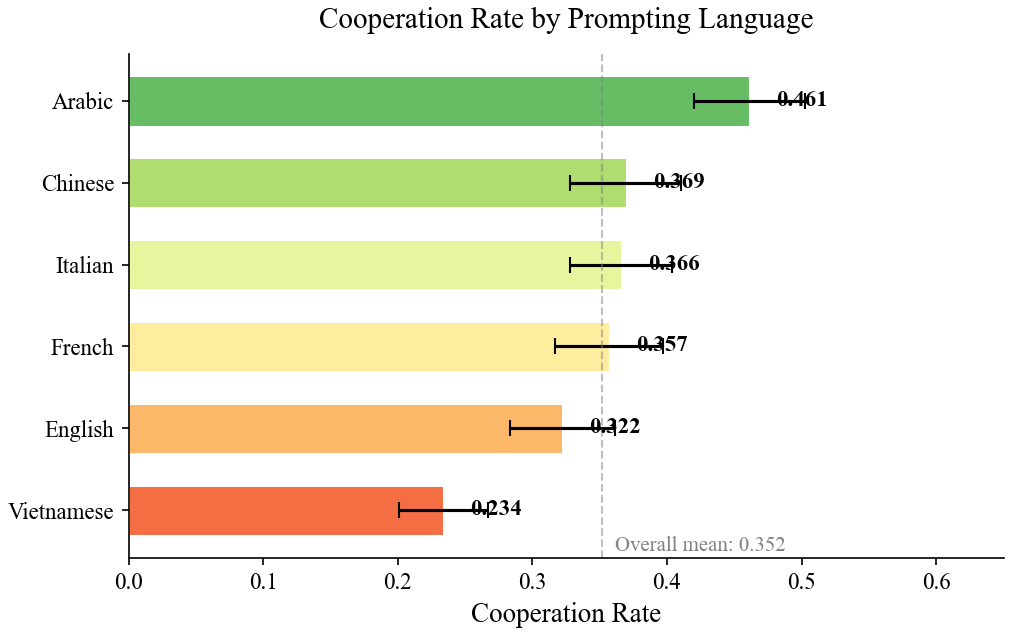

Saved: fig3a_language_ranking.pdf/png


In [3]:
# ── Figure 3a: Language ranking with CI ──
lang_stats = df.groupby('lang_full')['agent1_cooperation_rate'].agg(['mean', 'std', 'count']).reset_index()
lang_stats['se'] = lang_stats['std'] / np.sqrt(lang_stats['count'])
lang_stats = lang_stats.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(lang_stats)))

bars = ax.barh(
    lang_stats['lang_full'], lang_stats['mean'],
    xerr=lang_stats['se'] * 1.96, capsize=4,
    color=colors, edgecolor='white', linewidth=0.5, height=0.6
)

# Value labels
for bar, val in zip(bars, lang_stats['mean']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Cooperation Rate')
ax.set_title('Cooperation Rate by Prompting Language', fontsize=14, pad=12)
ax.set_xlim(0, 0.65)
ax.axvline(x=df['agent1_cooperation_rate'].mean(), color='gray',
           linestyle='--', alpha=0.5, linewidth=1)
ax.text(df['agent1_cooperation_rate'].mean() + 0.01, -0.5,
        f'Overall mean: {df["agent1_cooperation_rate"].mean():.3f}',
        fontsize=10, color='gray')

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig3a_language_ranking.pdf')
fig.savefig(f'{FIGURE_DIR}fig3a_language_ranking.png')
plt.show()
print('Saved: fig3a_language_ranking.pdf/png')

## 3.2 Figure 3b — Language × Model Interaction

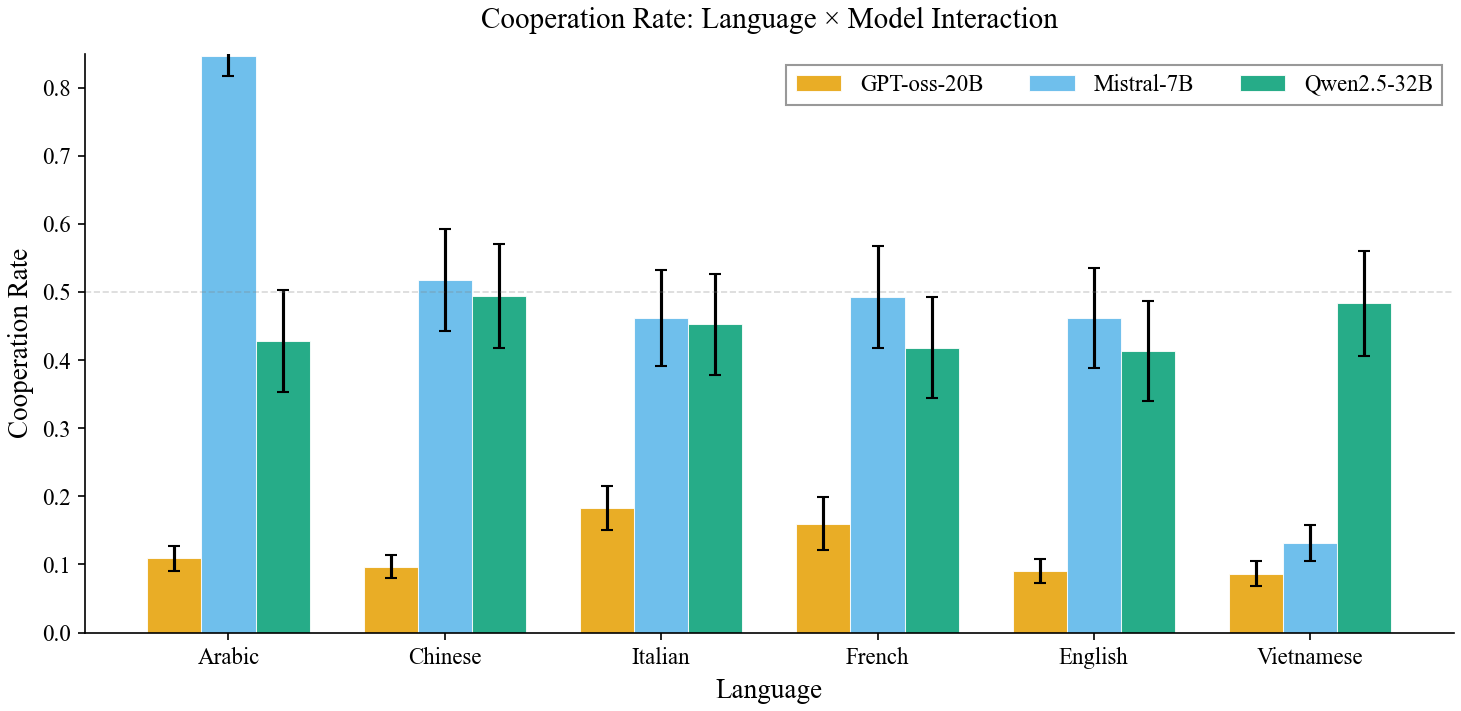

Saved: fig3b_language_model_interaction.pdf/png


In [4]:
# ── Figure 3b: Grouped bar — Language × Model ──
lang_order_by_mean = lang_stats.sort_values('mean', ascending=False)['lang_full'].tolist()
models_order = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(lang_order_by_mean))
width = 0.25

for i, model in enumerate(models_order):
    sub = df[df['model'] == model]
    means = [sub[sub['lang_full'] == lang]['agent1_cooperation_rate'].mean() for lang in lang_order_by_mean]
    sems = [sub[sub['lang_full'] == lang]['agent1_cooperation_rate'].sem() for lang in lang_order_by_mean]
    
    ax.bar(x + (i - 1) * width, means, width,
           yerr=np.array(sems) * 1.96, capsize=3,
           label=model, color=MODEL_COLORS[model],
           alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(lang_order_by_mean)
ax.set_xlabel('Language')
ax.set_ylabel('Cooperation Rate')
ax.set_title('Cooperation Rate: Language × Model Interaction', fontsize=14, pad=12)
ax.legend(frameon=True, fancybox=False, edgecolor='gray', ncol=3, loc='upper right')
ax.set_ylim(0, 0.85)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig3b_language_model_interaction.pdf')
fig.savefig(f'{FIGURE_DIR}fig3b_language_model_interaction.png')
plt.show()
print('Saved: fig3b_language_model_interaction.pdf/png')

## 3.3 Figure 3c — Full Heatmap: Language × Model × Noise

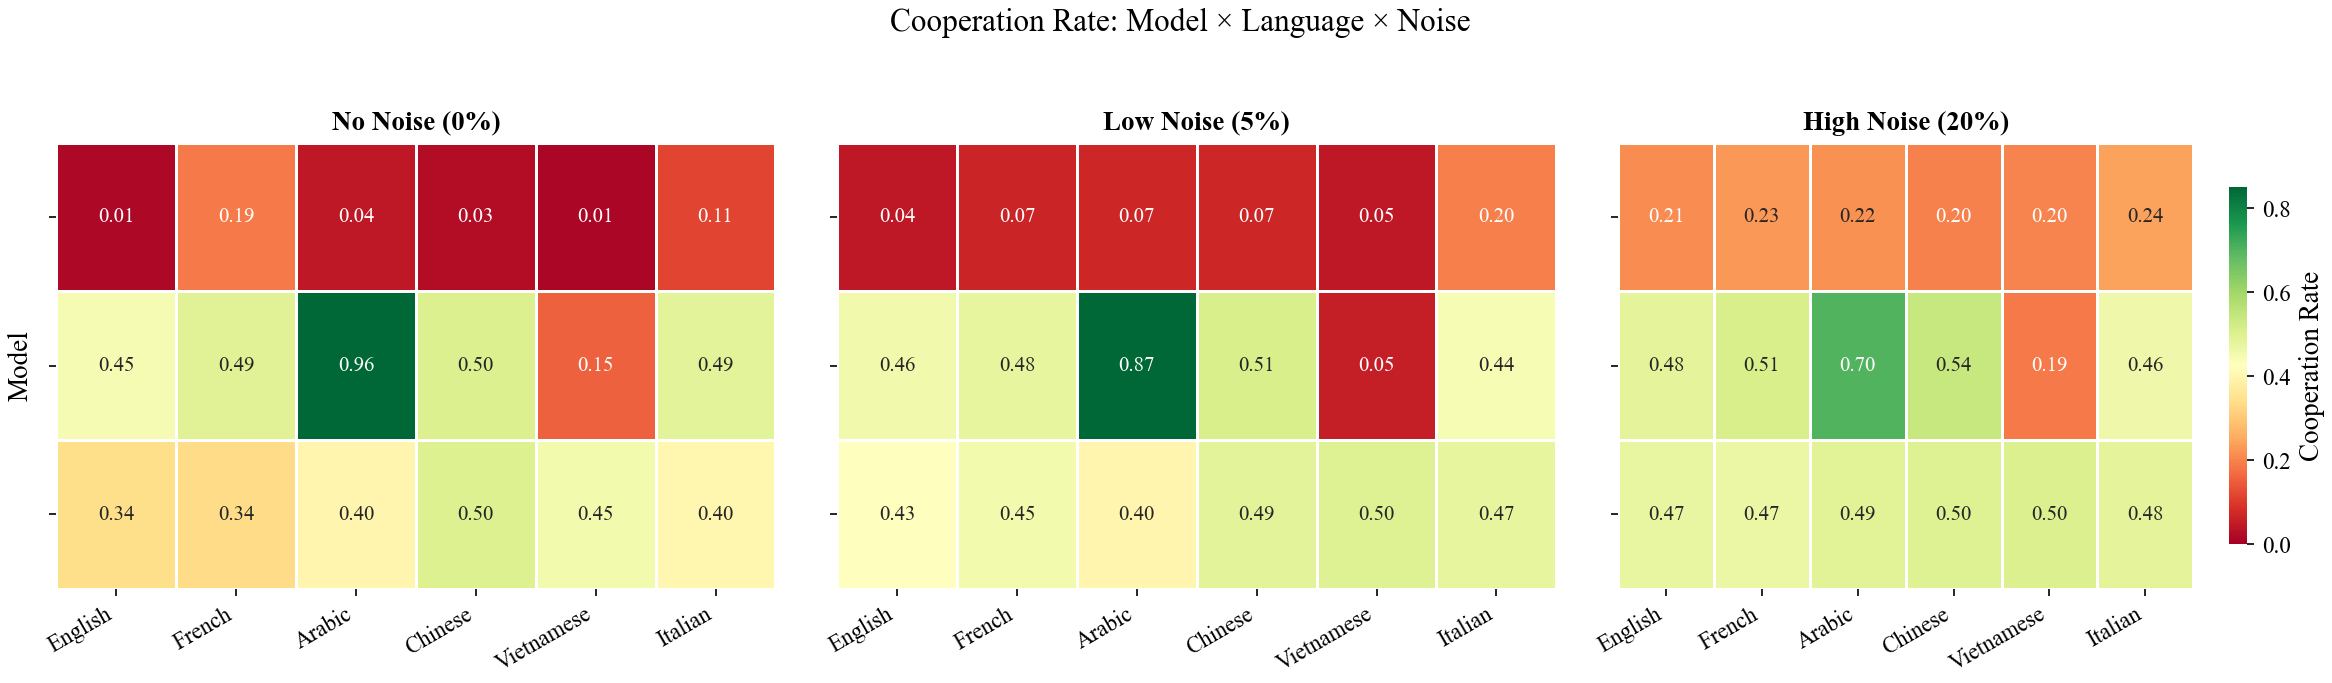

Saved: fig3c_language_model_noise_heatmap.pdf/png


In [5]:
# ── Figure 3c: Faceted heatmap — Language × Model for each noise level ──
noise_levels = [0.0, 0.05, 0.2]
noise_labels_short = {0.0: 'No Noise (0%)', 0.05: 'Low Noise (5%)', 0.2: 'High Noise (20%)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for idx, noise in enumerate(noise_levels):
    ax = axes[idx]
    sub = df[df['agent1_noise_rate'] == noise]
    pivot = sub.pivot_table(
        values='agent1_cooperation_rate',
        index='model', columns='lang_full', aggfunc='mean'
    ).reindex(models_order)[list(LANG_LABELS.values())]
    
    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=0, vmax=0.85, linewidths=0.5, linecolor='white',
        cbar=idx == 2,
        cbar_kws={'label': 'Cooperation Rate', 'shrink': 0.8} if idx == 2 else {},
        annot_kws={'fontsize': 10},
        ax=ax
    )
    ax.set_title(noise_labels_short[noise], fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('' if idx > 0 else 'Model')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

fig.suptitle('Cooperation Rate: Model × Language × Noise', fontsize=15, y=1.03)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig3c_language_model_noise_heatmap.pdf')
fig.savefig(f'{FIGURE_DIR}fig3c_language_model_noise_heatmap.png')
plt.show()
print('Saved: fig3c_language_model_noise_heatmap.pdf/png')

## 3.4 Statistical Tests — Language Effect

In [6]:
# ── Kruskal-Wallis: language effect overall ──
groups = [g['agent1_cooperation_rate'].values for _, g in df.groupby('language')]
H, p = stats.kruskal(*groups)
print(f'Kruskal-Wallis (Language effect): H = {H:.2f}, p = {p:.2e}')

# ── Post-hoc pairwise Mann-Whitney ──
print('\nPost-hoc pairwise Mann-Whitney U tests (Bonferroni-corrected):')
print('-' * 75)
langs = sorted(df['language'].unique())
n_comp = len(list(combinations(langs, 2)))
results_rows = []

for l1, l2 in combinations(langs, 2):
    g1 = df[df['language'] == l1]['agent1_cooperation_rate']
    g2 = df[df['language'] == l2]['agent1_cooperation_rate']
    U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    n1, n2 = len(g1), len(g2)
    r = 1 - (2 * U) / (n1 * n2)
    p_adj = min(p * n_comp, 1.0)
    sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
    results_rows.append({
        'Lang1': LANG_LABELS[l1], 'Lang2': LANG_LABELS[l2],
        'U': U, 'p_adj': p_adj, 'r': r, 'sig': sig
    })

pw_results = pd.DataFrame(results_rows)
display(pw_results.sort_values('p_adj'))

# ── Per-model language effect ──
print('\n\nKruskal-Wallis (Language effect) per model:')
print('-' * 50)
for model in ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']:
    sub = df[df['model'] == model]
    groups = [g['agent1_cooperation_rate'].values for _, g in sub.groupby('language')]
    H, p = stats.kruskal(*groups)
    eta2 = (H - len(groups) + 1) / (len(sub) - len(groups))  # eta-squared approximation
    print(f'  {model}: H={H:.2f}, p={p:.2e}, η²≈{eta2:.4f}')

Kruskal-Wallis (Language effect): H = 57.79, p = 3.48e-11

Post-hoc pairwise Mann-Whitney U tests (Bonferroni-corrected):
---------------------------------------------------------------------------


,Lang1,Lang2,U,p_adj,r,sig
4,Arabic,Vietnamese,84753.0,9.725184e-12,-0.307917,***
14,Italian,Vietnamese,78931.0,5.170166e-06,-0.218071,***
1,Arabic,English,77882.0,3.688914e-05,-0.201883,***
8,Chinese,Vietnamese,76028.0,7.567828e-04,-0.173272,***
13,French,Vietnamese,74876.5,4.104611e-03,-0.155502,**
2,Arabic,French,74099.5,1.227259e-02,-0.143511,*
0,Arabic,Chinese,72470.0,8.668000e-02,-0.118364,ns
3,Arabic,Italian,72241.5,1.118294e-01,-0.114838,ns
10,English,Italian,58045.5,2.236351e-01,0.104236,ns
11,English,Vietnamese,70980.5,3.807760e-01,-0.095378,ns




Kruskal-Wallis (Language effect) per model:
--------------------------------------------------
  GPT-oss-20B: H=31.23, p=8.42e-06, η²≈0.0367
  Mistral-7B: H=146.99, p=5.84e-30, η²≈0.1989
  Qwen2.5-32B: H=2.94, p=7.10e-01, η²≈-0.0029


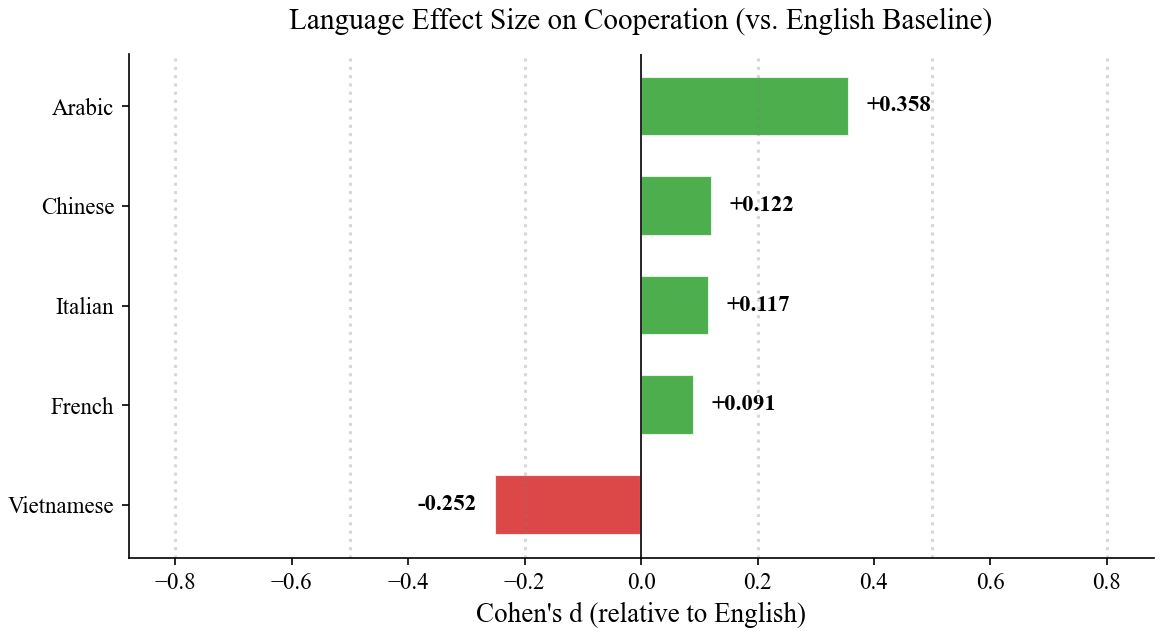

Saved: fig3d_language_effect_size.pdf/png


In [7]:
# ── Figure 3d: Language effect size (Cohen's d relative to English) ──
fig, ax = plt.subplots(figsize=(8, 4.5))

en_data = df[df['language'] == 'en']['agent1_cooperation_rate']
lang_effects = []
for lang in ['fr', 'ar', 'cn', 'vn', 'it']:
    lang_data = df[df['language'] == lang]['agent1_cooperation_rate']
    pooled_std = np.sqrt((en_data.std()**2 + lang_data.std()**2) / 2)
    d = (lang_data.mean() - en_data.mean()) / pooled_std
    lang_effects.append({'Language': LANG_LABELS[lang], 'Cohens_d': d})

effects_df = pd.DataFrame(lang_effects).sort_values('Cohens_d', ascending=True)
colors = ['#d62728' if d < 0 else '#2ca02c' for d in effects_df['Cohens_d']]

bars = ax.barh(effects_df['Language'], effects_df['Cohens_d'],
               color=colors, edgecolor='white', height=0.6, alpha=0.85)

for bar, val in zip(bars, effects_df['Cohens_d']):
    offset = 0.03 if val >= 0 else -0.03
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=11, fontweight='bold')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("Cohen's d (relative to English)")
ax.set_title('Language Effect Size on Cooperation (vs. English Baseline)', fontsize=14, pad=12)

# Effect size reference lines
for threshold, label in [(0.2, 'Small'), (0.5, 'Medium'), (0.8, 'Large')]:
    for sign in [1, -1]:
        ax.axvline(x=sign * threshold, color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig3d_language_effect_size.pdf')
fig.savefig(f'{FIGURE_DIR}fig3d_language_effect_size.png')
plt.show()
print('Saved: fig3d_language_effect_size.pdf/png')